In [1]:
def plot_graph(df, selected,color_c,y_lim_gen_2,y_lim_gen_10, info_p):
    
    fig, axes = plt.subplots(len(num_gen), len(b_r), figsize=(4 * len(b_r), 4 * len(num_gen)), sharex=True, sharey=False)

    for i, ng in enumerate(num_gen):
        for j, br in enumerate(b_r):
            ax = axes[i, j] if len(num_gen) > 1 else axes[j]

            folder = f"./results/IGD_{ng}_BR_{ng}_NH_{ng}_MxH_{ng}/"
            
            # Leer todos los archivos de esa carpeta
            files = [f for f in os.listdir(folder) if f.endswith('.txt')]
            df_list = [pd.read_csv(os.path.join(folder, f), sep=';', header=0) for f in files]
            df = pd.concat(df_list, ignore_index=True).fillna(0)

            for col in range(len(selected)):

                # Calcular media y desviación
                mean_df = df.groupby('time')[[selected[col]]].mean()
                std_df = df.groupby('time')[[selected[col]]].std()
                x = mean_df.index

                # Graficar cada línea con sombreado
                ax.plot(x, mean_df[selected[col]], color= color_c[col], linewidth=1.8)
                ax.fill_between(x, mean_df[selected[col]] - std_df[selected[col]],
                                mean_df[selected[col]] + std_df[selected[col]],
                                color=color_c[col], alpha=0.2)
            if(i == 0):
                ax.set_ylim(y_lim_gen_2)
            else:
                ax.set_ylim(y_lim_gen_10)
            # Personalización del subplot
            ax.set_title(f"Genomas: {ng} | BR: {br}", fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.4)

            # Etiquetas solo en bordes
            if i == len(num_gen) - 1:
                ax.set_xlabel("Tiempo (días)")


    # Ajustes generales
    handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(selected[0], fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])
    plt.savefig("./Figures/" + selected[0] +"_"+ info_p + ".jpg", dpi = 300, bbox_inches = "tight")
    plt.show()

In [2]:
def plot_graph_IBD(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p):
    
    fig, axes = plt.subplots(len(num_gen), len(b_r), figsize=(4 * len(b_r), 4 * len(num_gen)), sharex=True, sharey=False)

    for i, ng in enumerate(num_gen):
        for j, br in enumerate(b_r):
            ax = axes[i, j] if len(num_gen) > 1 else axes[j]
            folder = f"./results/num_genomes_{ng}_bitting_rate_{br}/"

            # Leer todos los archivos de esa carpeta
            files = [f for f in os.listdir(folder) if f.endswith('.txt')]
            df_list = [pd.read_csv(os.path.join(folder, f), sep=';', header=0) for f in files]
            df = pd.concat(df_list, ignore_index=True).fillna(0)
            
            if(ng == 2):
                selected_v = selected[0:2]
            else: 
                selected_v = selected[:]
                
            for col in range(len(selected_v)):
                # Calcular media y desviación
                mean_df = df.groupby('time')[[selected_v[col]]].mean()
                std_df = df.groupby('time')[[selected_v[col]]].std()
                x = mean_df.index

                # Graficar cada línea con sombreado
                ax.plot(x, mean_df[selected_v[col]], color= color_c[col], linewidth=1.8)
                ax.fill_between(x, mean_df[selected_v[col]] - std_df[selected_v[col]],
                                mean_df[selected_v[col]] + std_df[selected_v[col]],
                                color=color_c[col], alpha=0.2)
            if(i == 0):
                ax.set_ylim(y_lim_gen_2)
            else:
                ax.set_ylim(y_lim_gen_10)
            # Personalización del subplot
            ax.set_title(f"Genomas: {ng} | BR: {br}", fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.4)

            # Etiquetas solo en bordes
            if i == len(num_gen) - 1:
                ax.set_xlabel("Tiempo (días)")


    # Ajustes generales
    handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(selected[0], fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])
    plt.savefig("./Figures/" + selected[0] + info_p +"_" ".jpg", dpi = 300, bbox_inches = "tight")


    plt.show()

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Parámetros de simulación
num_gen = [2, 10]
b_r = [0.1, 0.2, 0.3, 0.4, 0.5]
#b_r = [0.6, 0.7, 0.8, 0.9, 1.0]
#b_r = [1.1, 1.2, 1.3, 1.4, 1.5]
#b_r = [1.6, 1.7, 1.8, 1.9, 2.0]
#b_r = [3.0, 4.0, 6.0, 7.0, 8.0]
#b_r = [9.0, 10.0, 20.0, 30.0, 40.0]

info_p = "_".join(str(v) for v in b_r)

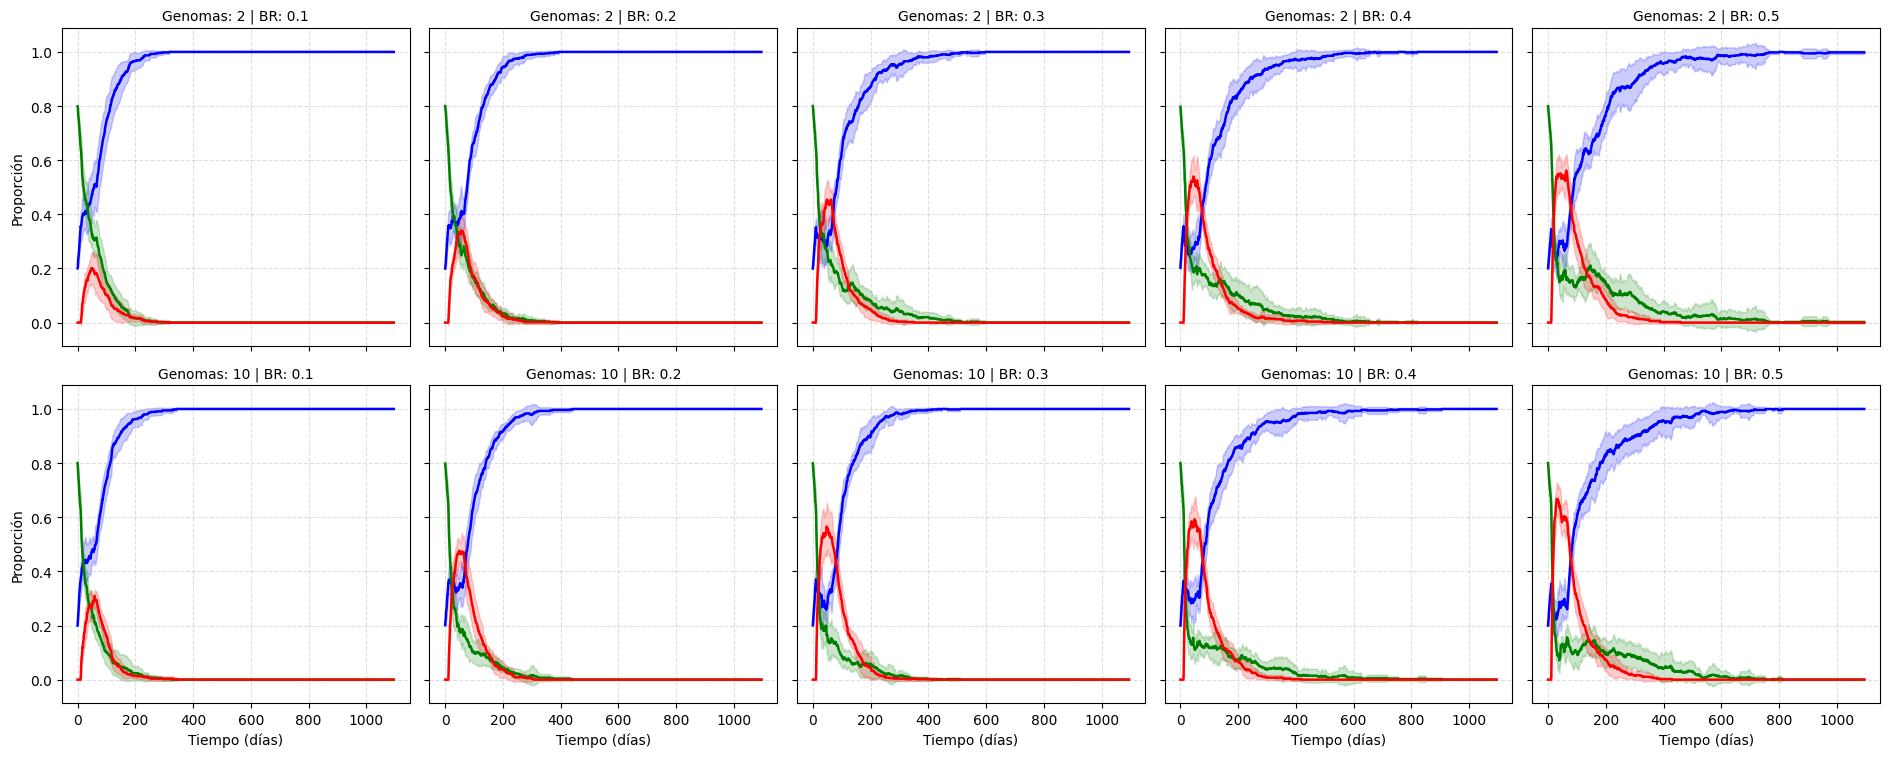

In [4]:
# Crear figura con subplots: filas = num_gen, columnas = b_r
fig, axes = plt.subplots(len(num_gen), len(b_r), figsize=(4 * len(b_r),
                                                          4 * len(num_gen)), sharex=True, sharey=True)

for i, ng in enumerate(num_gen):
    for j, br in enumerate(b_r):
        ax = axes[i, j] if len(num_gen) > 1 else axes[j]
        folder = f"./results/num_genomes_{ng}_bitting_rate_{br}/"

        # Leer todos los archivos de esa carpeta
        files = [f for f in os.listdir(folder) if f.endswith('.txt')]
        df_list = [pd.read_csv(os.path.join(folder, f), sep=';', header=0) for f in files]
        df = pd.concat(df_list, ignore_index=True).fillna(0)

        # Calcular media y desviación
        mean_df = df.groupby('time')[['HS', 'HM', 'HPC']].mean() / 50
        std_df = df.groupby('time')[['HS', 'HM', 'HPC']].std() / 50
        x = mean_df.index

        # Graficar cada línea con sombreado
        ax.plot(x, mean_df['HS'], color='blue', label='HS', linewidth=1.8)
        ax.fill_between(x, mean_df['HS'] - std_df['HS'], mean_df['HS'] + std_df['HS'], color='blue', alpha=0.2)
        ax.plot(x, mean_df['HM'], color='green', label='HM', linewidth=1.8)
        ax.fill_between(x, mean_df['HM'] - std_df['HM'], mean_df['HM'] + std_df['HM'], color='green', alpha=0.2)
        ax.plot(x, mean_df['HPC'], color='red', label='HPC', linewidth=1.8)
        ax.fill_between(x, mean_df['HPC'] - std_df['HPC'], mean_df['HPC'] + std_df['HPC'], color='red', alpha=0.2)

        # Personalización del subplot
        ax.set_title(f"Genomas: {ng} | BR: {br}", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)

        # Etiquetas solo en bordes
        if i == len(num_gen) - 1:
            ax.set_xlabel("Tiempo (días)")
        if j == 0:
            ax.set_ylabel("Proporción")

# Ajustes generales
handles, labels = ax.get_legend_handles_labels()

#fig.suptitle("Dinámicas Epidemiológicas de Humanos", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.96])

plt.savefig("./Figures/Humans_Epi_" + info_p + ".jpg", dpi = 300, bbox_inches = "tight")
plt.show()

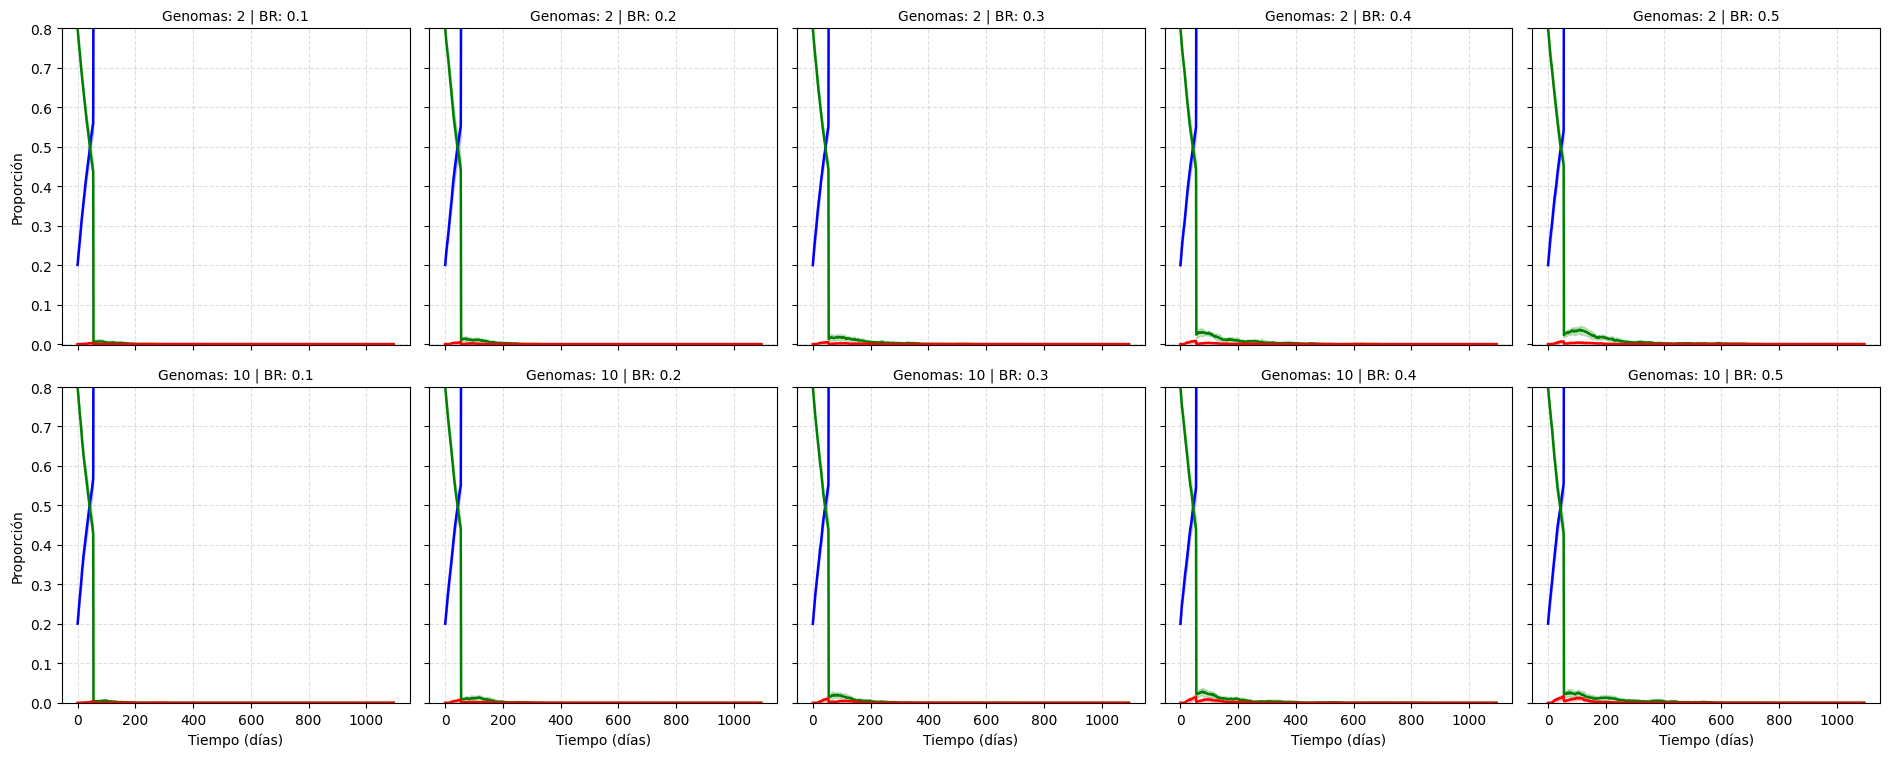

In [5]:
# Crear figura con subplots: filas = num_gen, columnas = b_r
fig, axes = plt.subplots(len(num_gen), len(b_r), figsize=(4 * len(b_r), 4 * len(num_gen)), sharex=True, sharey=True)

for i, ng in enumerate(num_gen):
    for j, br in enumerate(b_r):
        ax = axes[i, j] if len(num_gen) > 1 else axes[j]
        folder = f"./results/num_genomes_{ng}_bitting_rate_{br}/"

        # Leer todos los archivos de esa carpeta
        files = [f for f in os.listdir(folder) if f.endswith('.txt')]
        df_list = [pd.read_csv(os.path.join(folder, f), sep=';', header=0) for f in files]
        df = pd.concat(df_list, ignore_index=True).fillna(0)

        # Calcular media y desviación
        mean_df = df.groupby('time')[['MS', 'MC', 'MPC']].mean() / 350
        std_df = df.groupby('time')[['MS', 'MC', 'MPC']].std() / 350
        x = mean_df.index

        # Graficar cada línea con sombreado
        ax.plot(x, mean_df['MS'], color='blue', label='MS', linewidth=1.8)
        ax.fill_between(x, mean_df['MS'] - std_df['MS'], mean_df['MS'] + std_df['MS'], color='blue', alpha=0.2)
        ax.plot(x, mean_df['MC'], color='green', label='MC', linewidth=1.8)
        ax.fill_between(x, mean_df['MC'] - std_df['MC'], mean_df['MC'] + std_df['MC'], color='green', alpha=0.2)
        ax.plot(x, mean_df['MPC'], color='red', label='MPC', linewidth=1.8)
        ax.fill_between(x, mean_df['MPC'] - std_df['MPC'], mean_df['MPC'] + std_df['MPC'], color='red', alpha=0.2)
        
        ax.set_ylim(-0.001,0.8)
        # Personalización del subplot
        ax.set_title(f"Genomas: {ng} | BR: {br}", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)

        # Etiquetas solo en bordes
        if i == len(num_gen) - 1:
            ax.set_xlabel("Tiempo (días)")
        if j == 0:
            ax.set_ylabel("Proporción")

# Ajustes generales
handles, labels = ax.get_legend_handles_labels()

#fig.suptitle("Dinámicas Epidemiológicas de Humanos", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.savefig("./Figures/Mosquitoes_Epi_" + info_p + ".jpg", dpi = 300, bbox_inches = "tight")
plt.show()

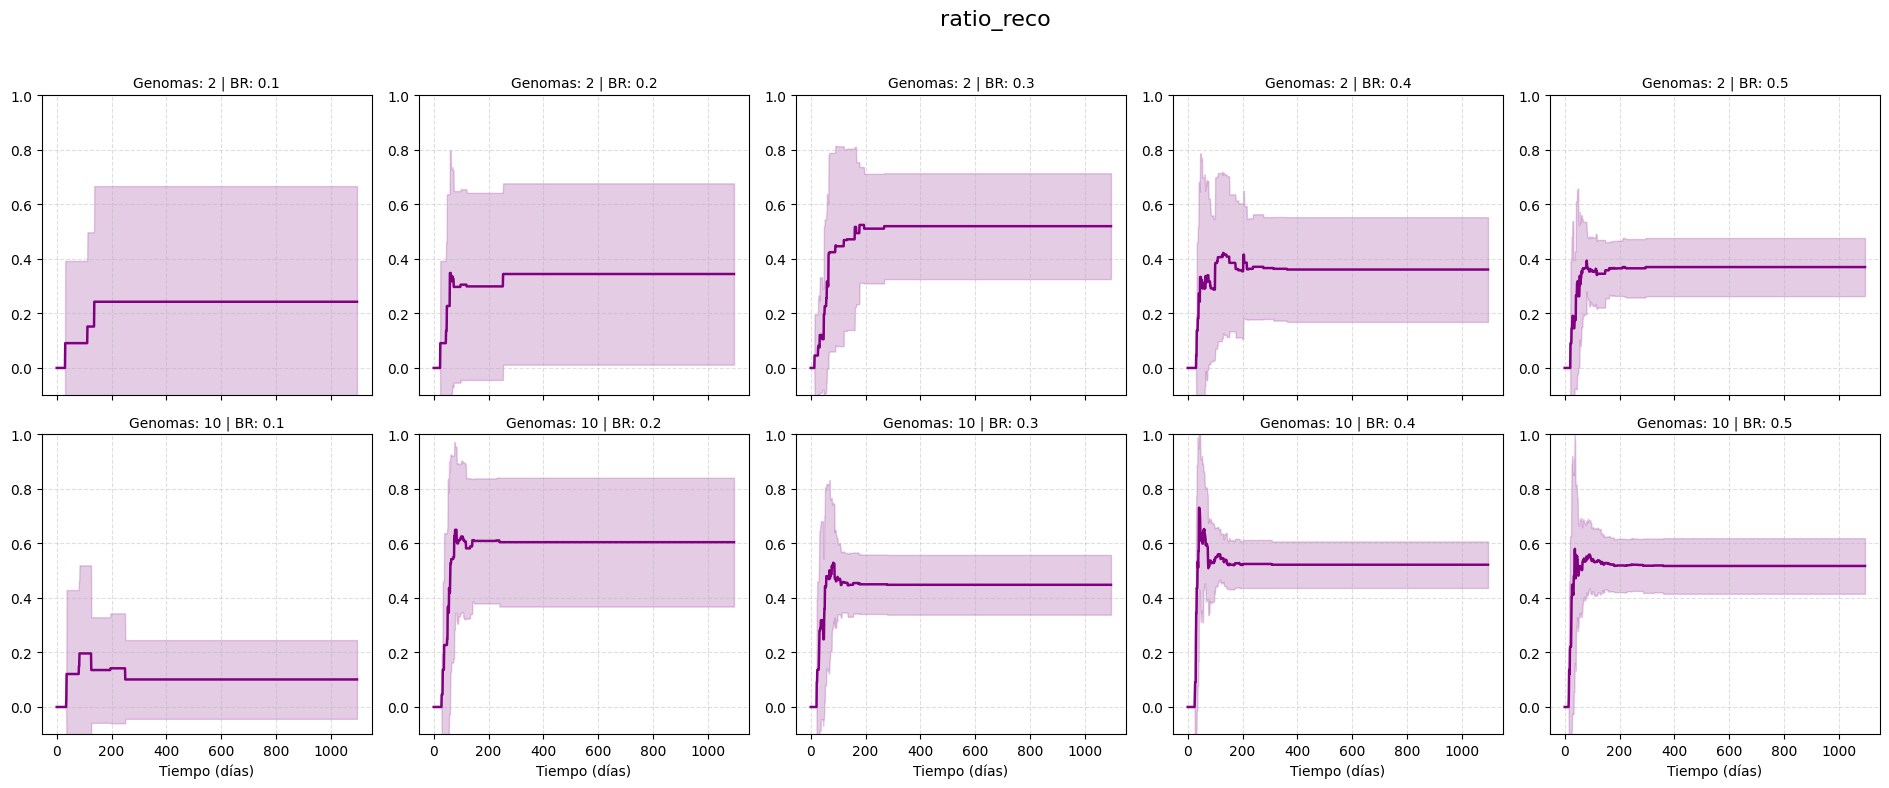

In [6]:
selected = ['ratio_reco']
color_c = ['purple']
y_lim_gen_2 = [-0.1,1.0]
y_lim_gen_10 = [-0.1,1.0]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

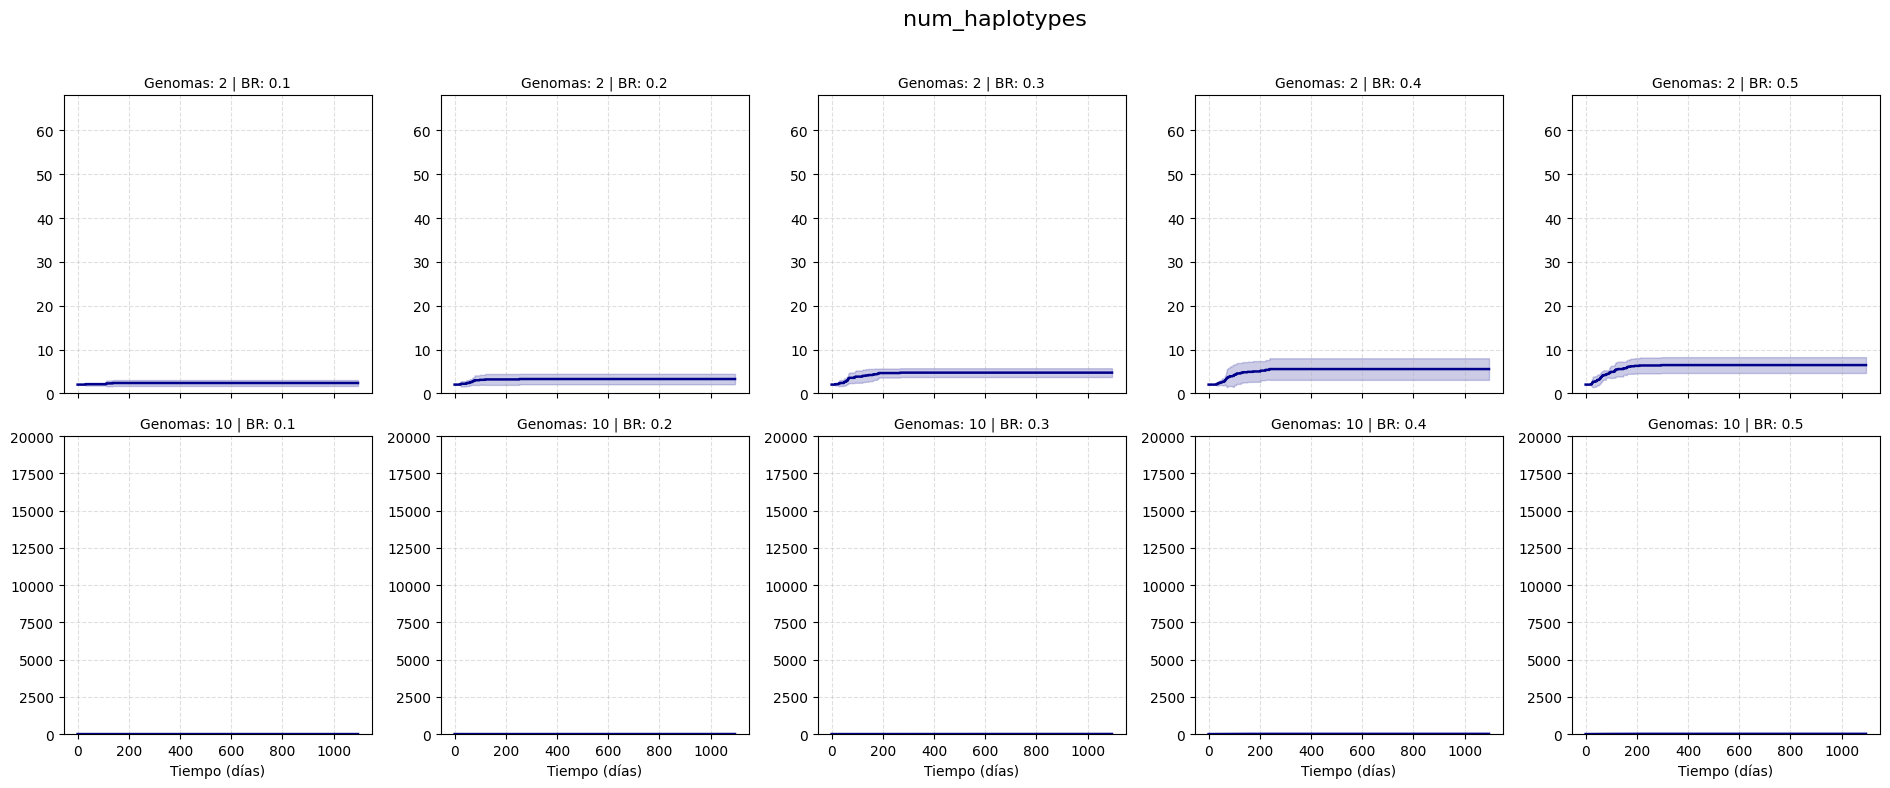

In [7]:
selected = ['num_haplotypes']
color_c = ['darkblue']
y_lim_gen_2 = [0,68]
y_lim_gen_10 = [0,20000]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

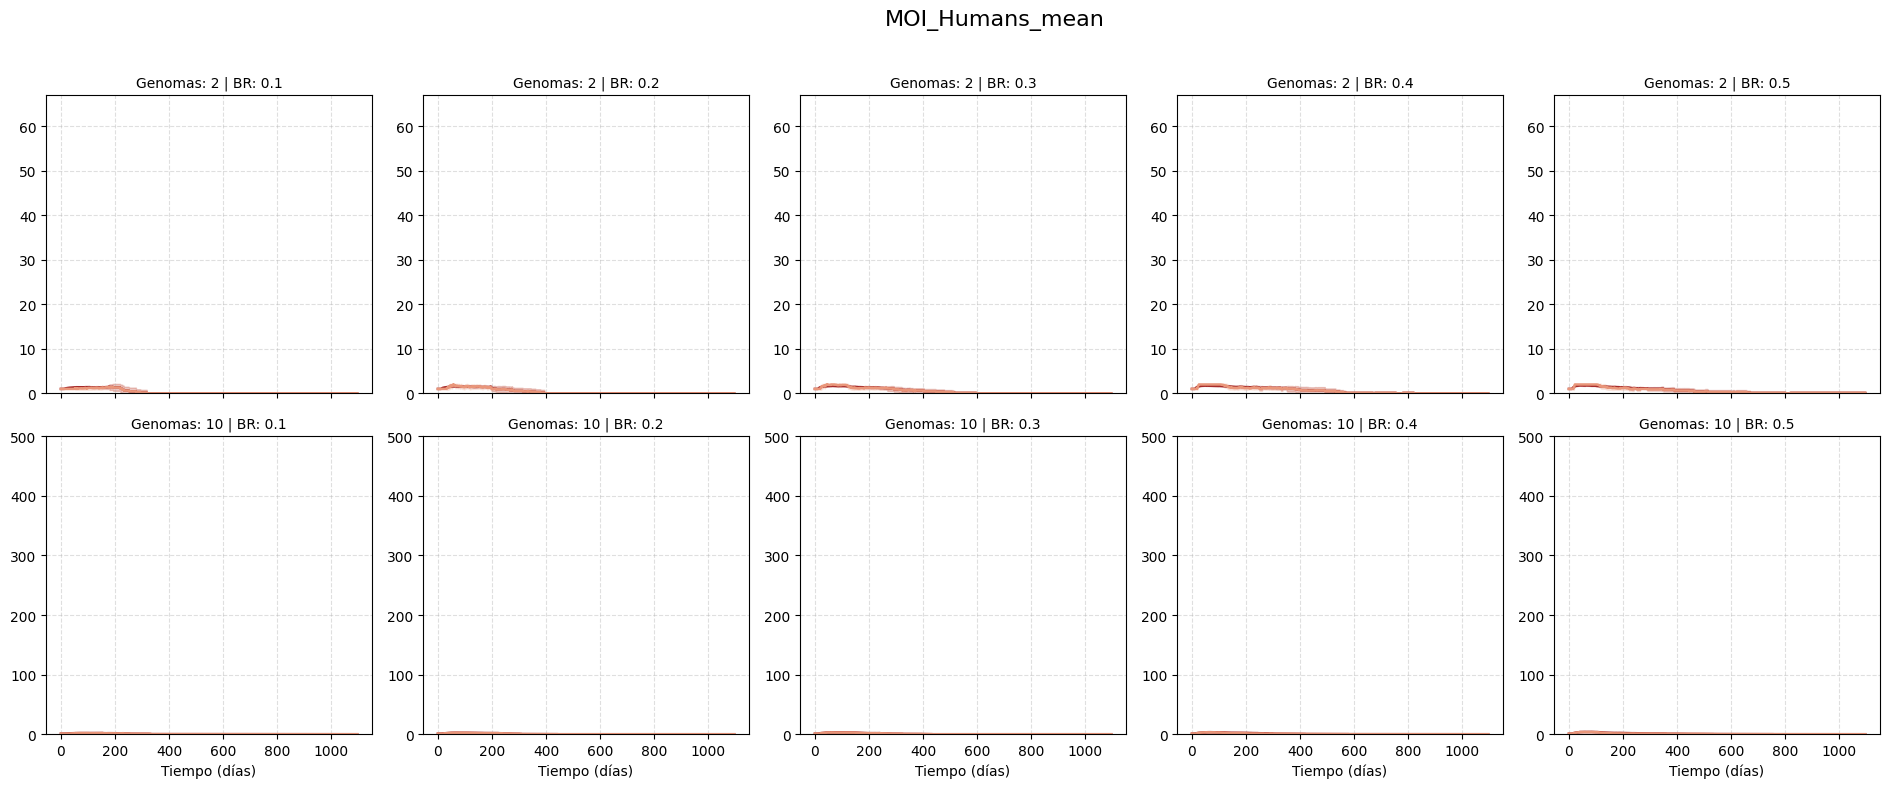

In [8]:
selected = ['MOI_Humans_mean', 'MOI_Humans_median']
color_c = ['brown',"darksalmon"]
y_lim_gen_2 = [0,67]
y_lim_gen_10 = [0,500]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

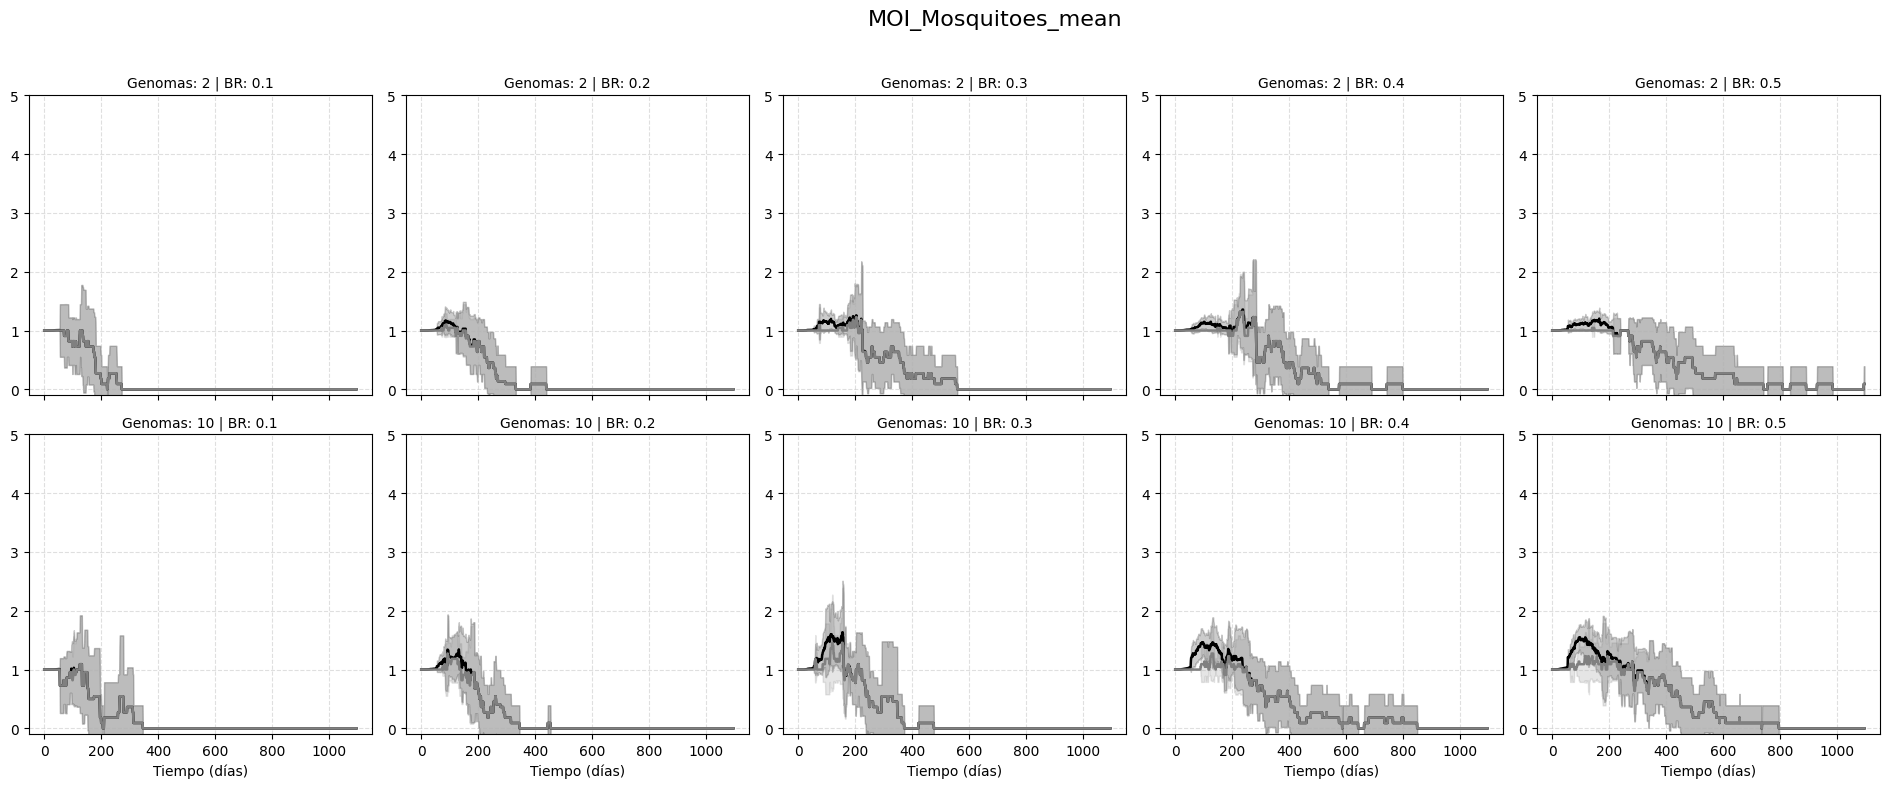

In [9]:
selected = ['MOI_Mosquitoes_mean', 'MOI_Mosquitoes_median']
color_c = ['black',"gray"]
y_lim_gen_2 = [-0.1,5]
y_lim_gen_10 = [-0.1,5]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

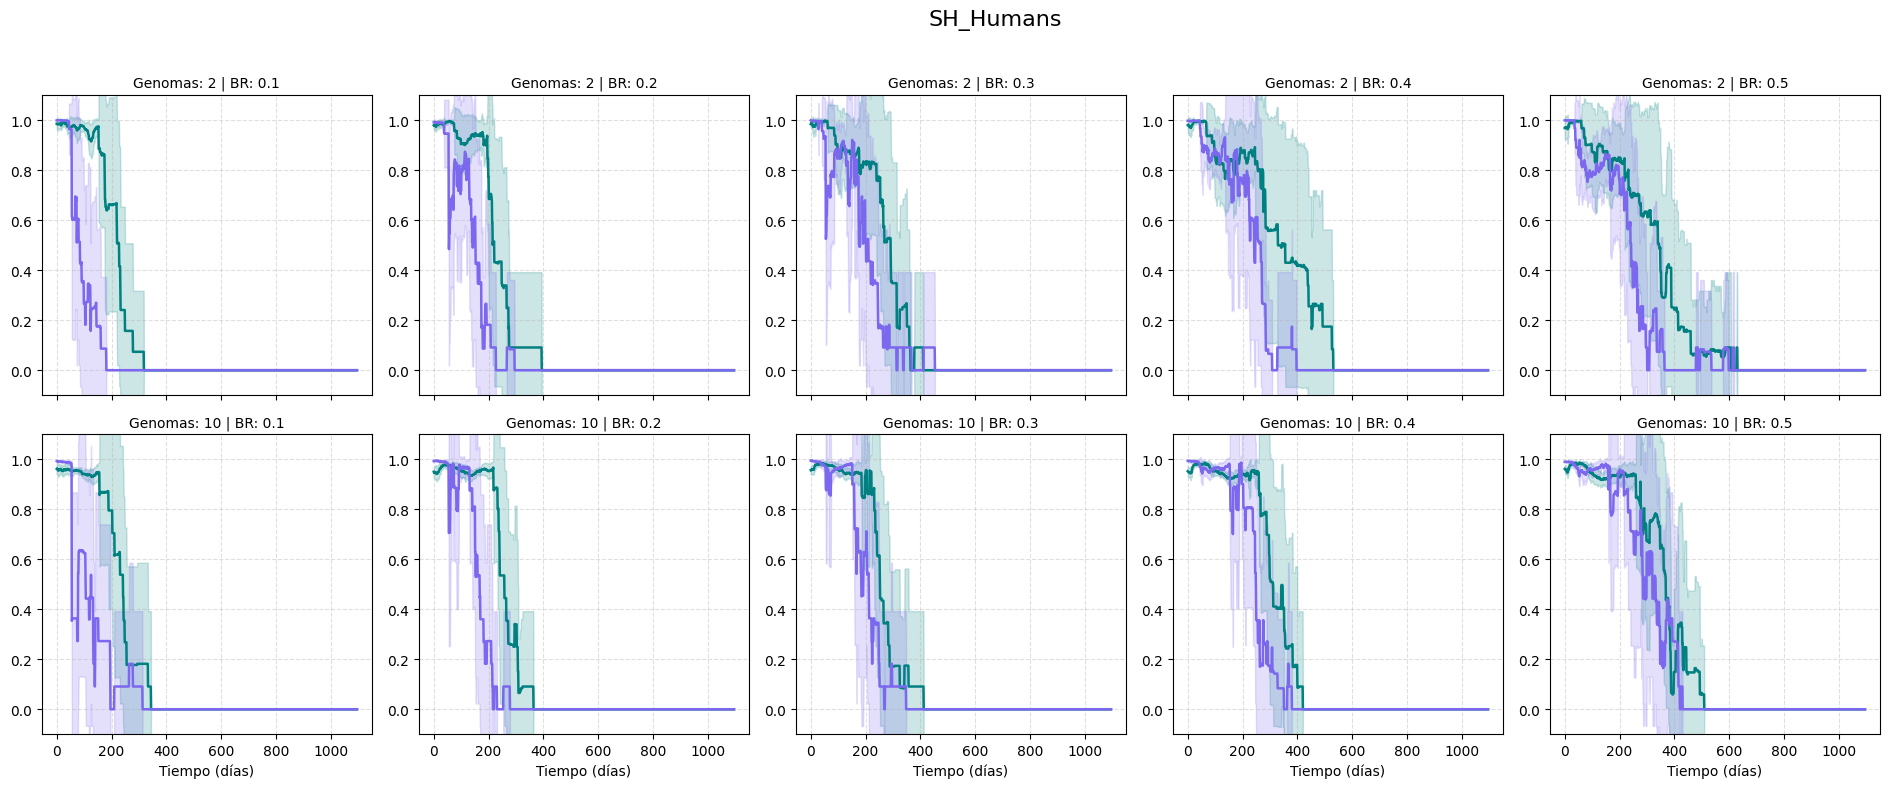

In [10]:
selected = ['SH_Humans','SH_Mosquitoes']
color_c = ['teal',"mediumslateblue"]
y_lim_gen_2 = [-0.1,1.1]
y_lim_gen_10 = [-0.1,1.1]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

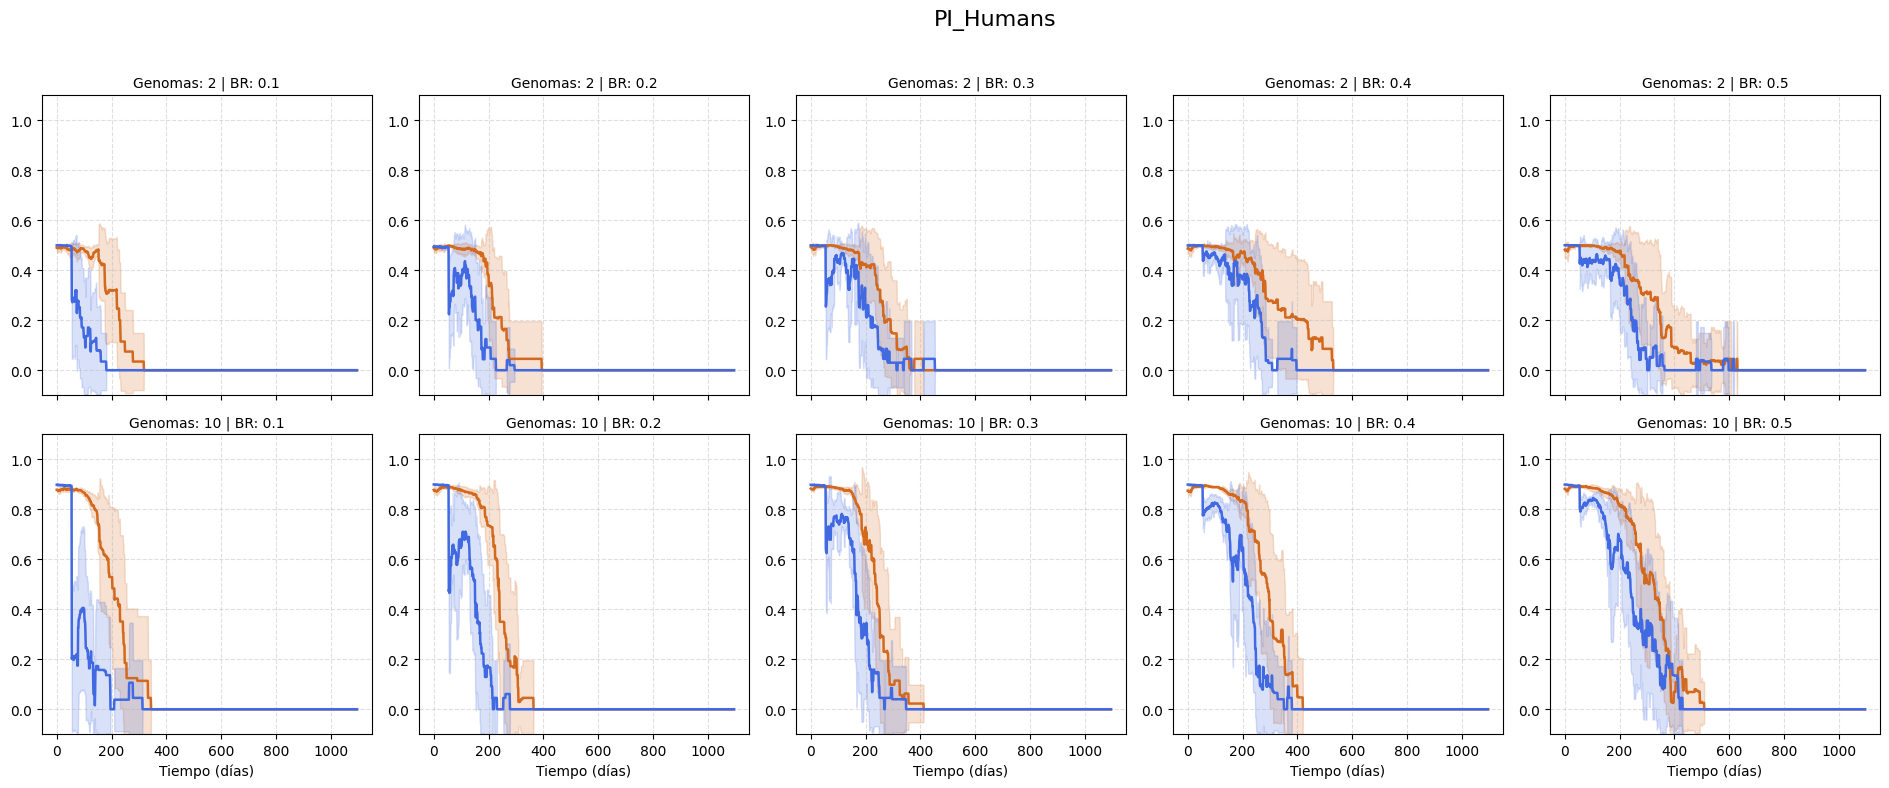

In [11]:
selected = ['PI_Humans', 'PI_Mosquitoes']
color_c = ['chocolate',"royalblue"]
y_lim_gen_2 = [-0.1,1.1]
y_lim_gen_10 = [-0.1,1.1]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

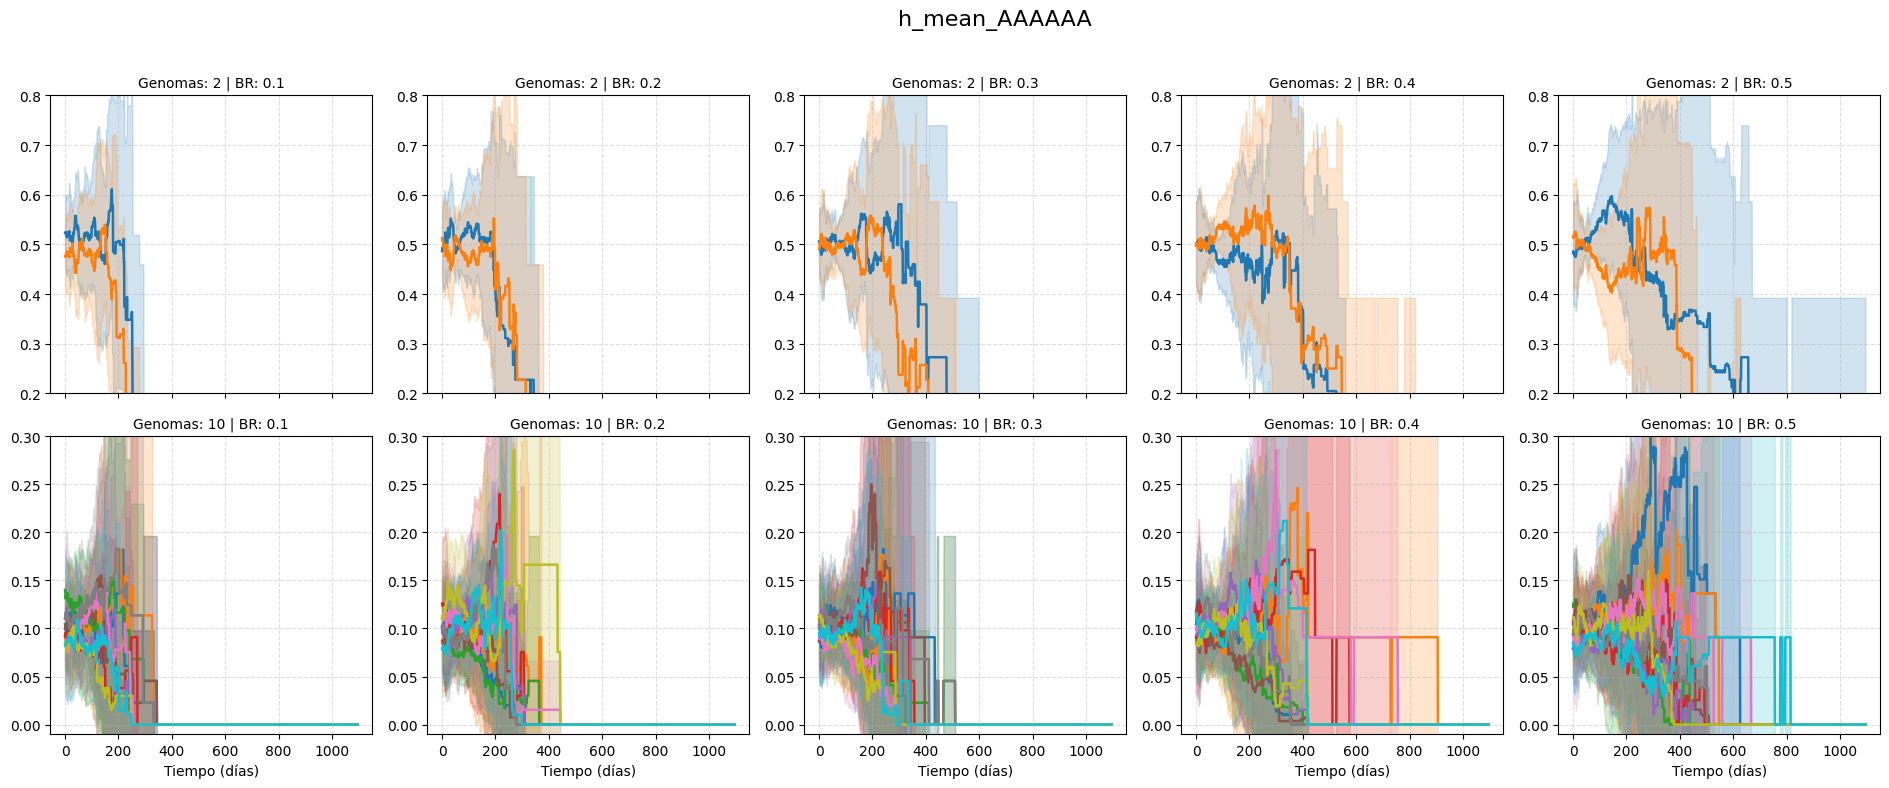

In [12]:
selected = ['h_mean_AAAAAA','h_mean_BBBBBB', 'h_mean_CCCCCC', 'h_mean_DDDDDD', 'h_mean_EEEEEE',
            'h_mean_FFFFFF', 'h_mean_GGGGGG', 'h_mean_HHHHHH', 'h_mean_IIIIII','h_mean_JJJJJJ']
color_c = ['#1f77b4',  '#ff7f0e','#2ca02c','#d62728','#9467bd', '#8c564b', 
           '#e377c2',  '#7f7f7f',  '#bcbd22', '#17becf']

y_lim_gen_2 = [0.2,0.8]
y_lim_gen_10 = [-0.01,0.3]

plot_graph_IBD(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

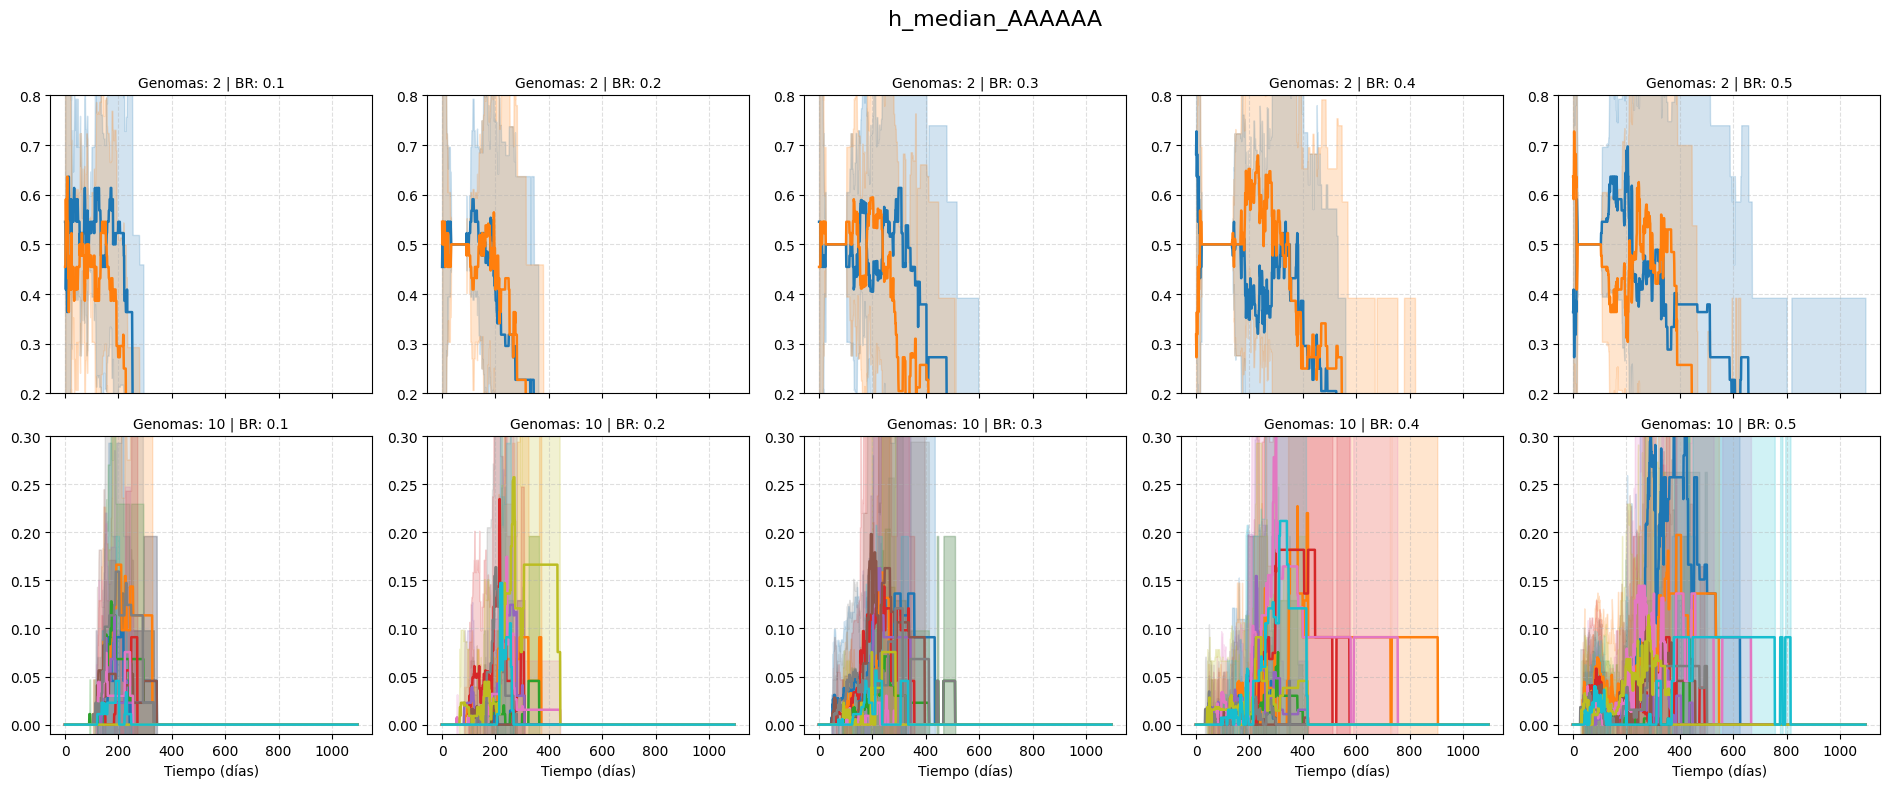

In [13]:
selected = ['h_median_AAAAAA', 'h_median_BBBBBB',
       'h_median_CCCCCC', 'h_median_DDDDDD', 'h_median_EEEEEE',
       'h_median_FFFFFF', 'h_median_GGGGGG', 'h_median_HHHHHH',
       'h_median_IIIIII', 'h_median_JJJJJJ']
color_c = ['#1f77b4',  '#ff7f0e','#2ca02c','#d62728','#9467bd', '#8c564b', 
           '#e377c2',  '#7f7f7f',  '#bcbd22', '#17becf']

y_lim_gen_2 = [0.2,0.8]
y_lim_gen_10 = [-0.01,0.3]

plot_graph_IBD(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

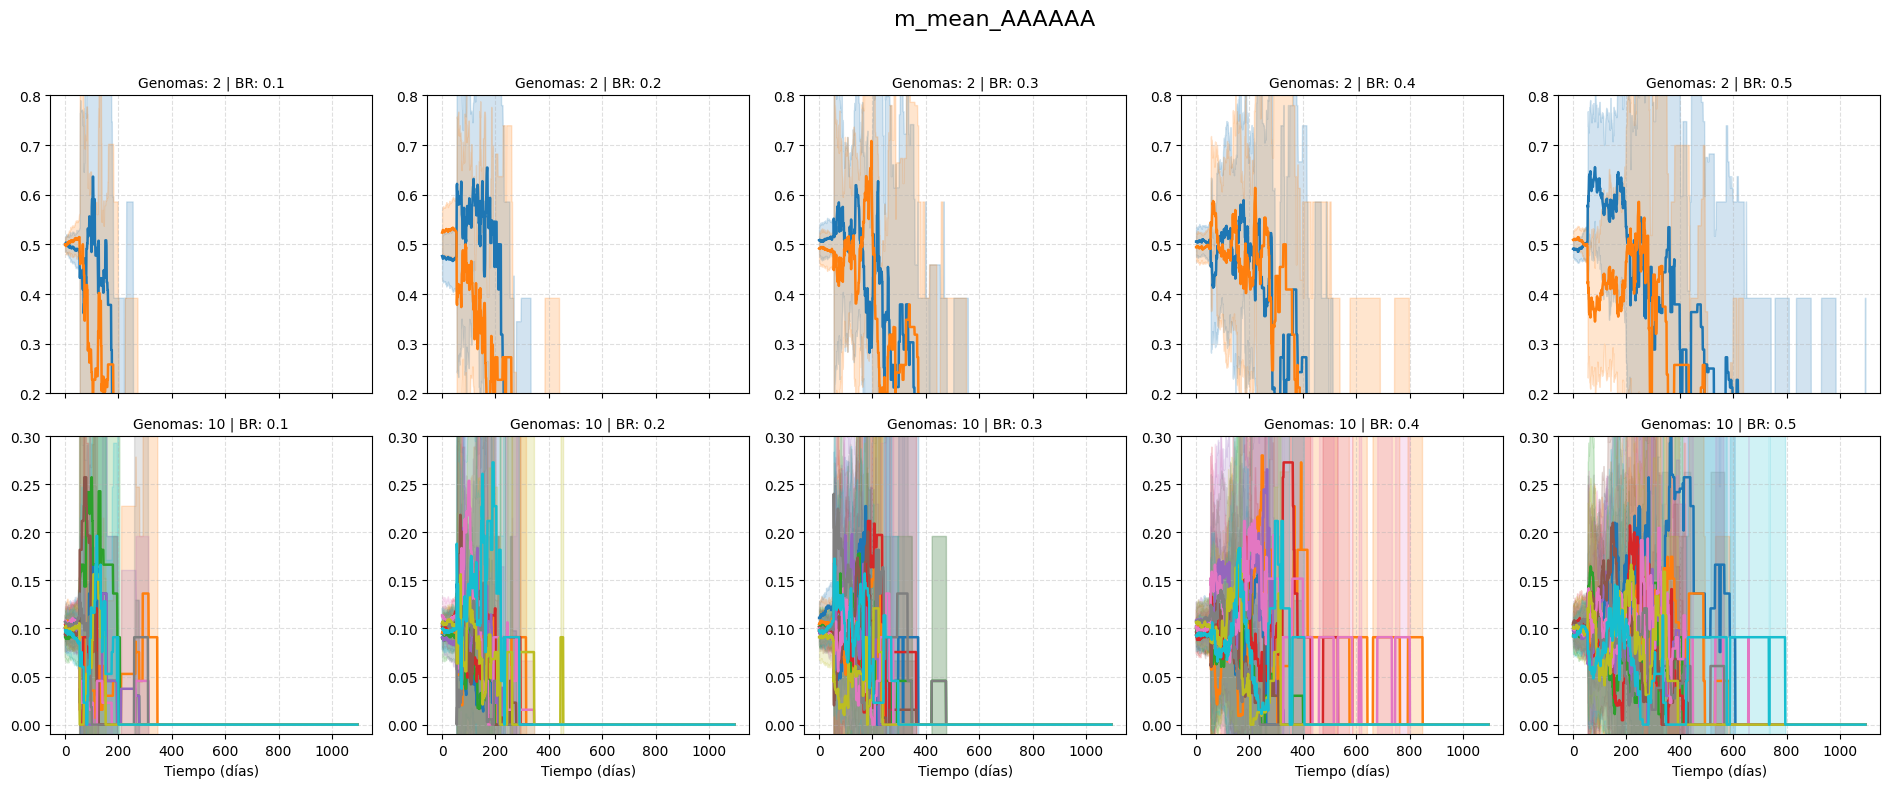

In [14]:
selected = ['m_mean_AAAAAA', 'm_mean_BBBBBB','m_mean_CCCCCC', 'm_mean_DDDDDD', 'm_mean_EEEEEE', 'm_mean_FFFFFF',
       'm_mean_GGGGGG', 'm_mean_HHHHHH', 'm_mean_IIIIII', 'm_mean_JJJJJJ']
color_c = ['#1f77b4',  '#ff7f0e','#2ca02c','#d62728','#9467bd', '#8c564b', 
           '#e377c2',  '#7f7f7f',  '#bcbd22', '#17becf']

y_lim_gen_2 = [0.2,0.8]
y_lim_gen_10 = [-0.01,0.3]

plot_graph_IBD(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

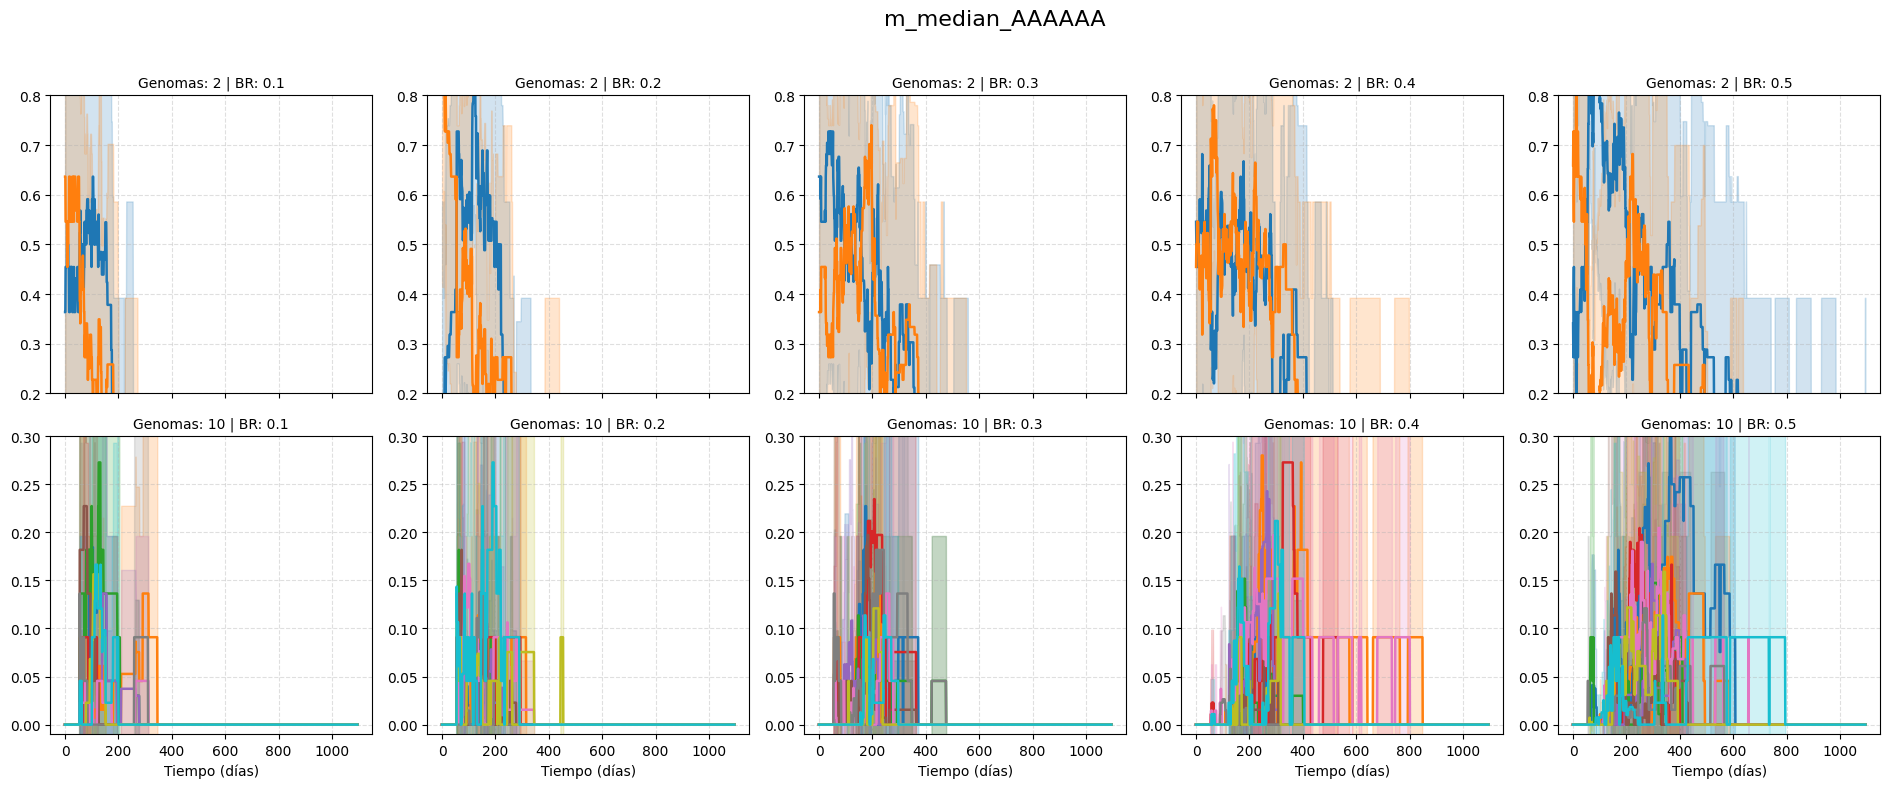

In [15]:
selected = ['m_median_AAAAAA', 'm_median_BBBBBB', 'm_median_CCCCCC',
       'm_median_DDDDDD', 'm_median_EEEEEE', 'm_median_FFFFFF',
       'm_median_GGGGGG', 'm_median_HHHHHH', 'm_median_IIIIII',
       'm_median_JJJJJJ']
color_c = ['#1f77b4',  '#ff7f0e','#2ca02c','#d62728','#9467bd', '#8c564b', 
           '#e377c2',  '#7f7f7f',  '#bcbd22', '#17becf']

y_lim_gen_2 = [0.2,0.8]
y_lim_gen_10 = [-0.01,0.3]

plot_graph_IBD(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

In [16]:
df[["time","lambda_v","lambda_h"]].head()

,time,lambda_v,lambda_h
0,0.0,0.45,68.50
1,0.0,0.45,68.50
2,1.0,0.45,67.77
3,2.0,0.44,67.03
4,3.0,0.41,66.30


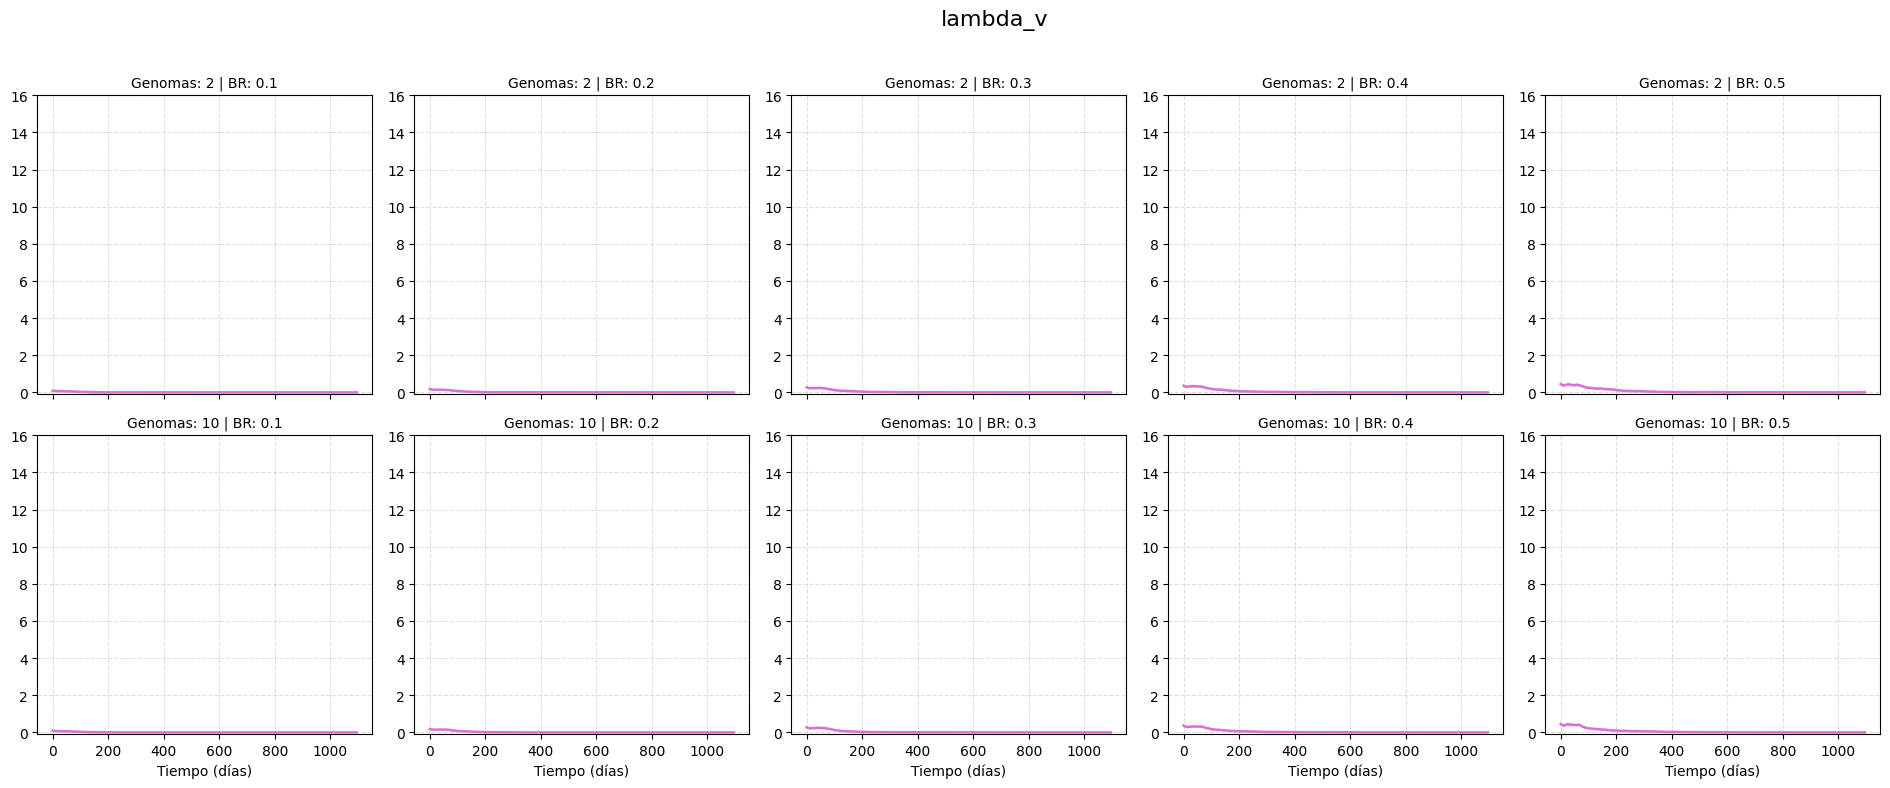

In [17]:
selected = ["lambda_v"]
color_c = ['orchid']
y_lim_gen_2 = [-0.1,16]
y_lim_gen_10 = [-0.1,16]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)

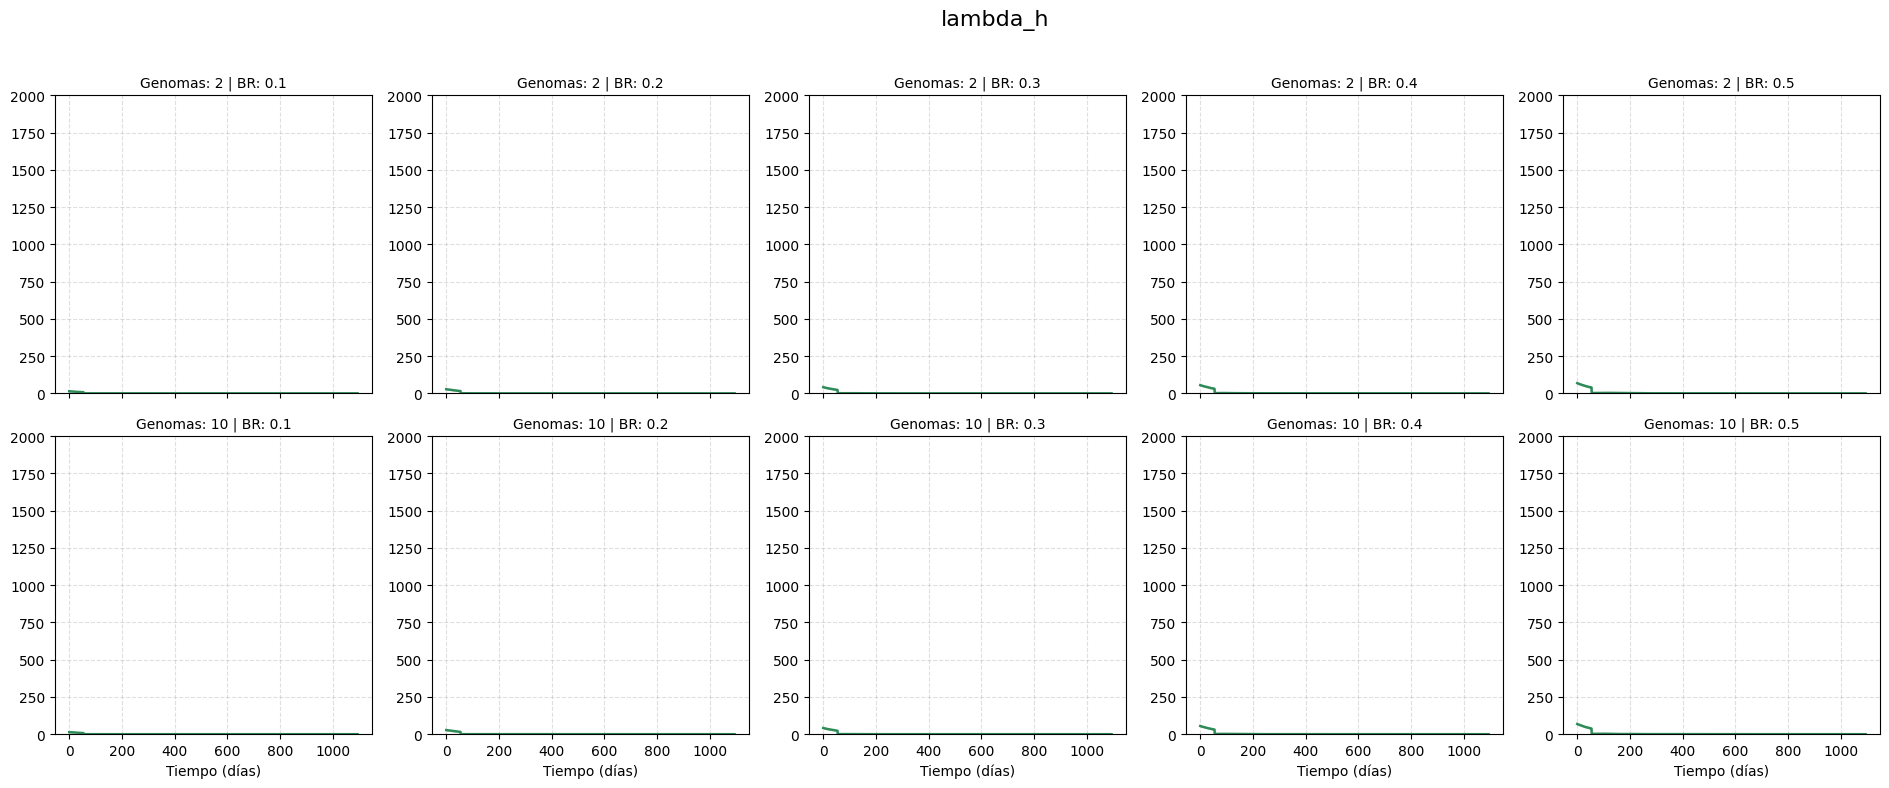

In [18]:
selected = ["lambda_h"]
color_c = ['seagreen']
y_lim_gen_2 = [-0.1,2000]
y_lim_gen_10 = [-0.1,2000]

plot_graph(df,selected,color_c,y_lim_gen_2,y_lim_gen_10,info_p)